# A3. Zhang–Duan 2009 high-pressure H₂O–CO₂ fluid

The Zhang–Duan (2009, ZD09) model is a corresponding-states equation of state calibrated for homogeneous C–O–H fluids at the high temperatures and pressures relevant to the upper mantle. The [original study](https://doi.org/10.1016/j.gca.2009.01.021) combines experimental and molecular-dynamics PVT data rather than extrapolating an EOS fitted only at low pressure.

This demonstration follows an equimolar H₂O–CO₂ fluid at

$$
T=1573.15\ \mathrm{K},\qquad (x_{\mathrm{H_2O}},x_{\mathrm{CO_2}})=(0.5,0.5),\qquad P=1\ \mathrm{MPa}\text{--}10\ \mathrm{GPa}.
$$

These limits match the H₂O–CO₂ mixture range reported by Zhang and Duan: 673–2573 K and 1 MPa–10 GPa. The composition is frozen, so no reaction, chemical-speciation, or phase-equilibrium calculation is performed. ExoEOS inputs use SI units; the pressure axis is converted to GPa only for display.


## Corresponding-states mixture model

ZD09 evaluates one 15-coefficient PVT expression in reduced temperature and density. A mixture is mapped to those reduced variables through effective energy and diameter parameters,

$$
\epsilon_{\mathrm{mix}}=\sum_i\sum_j x_i x_j k_{1,ij}\sqrt{\epsilon_i\epsilon_j},\qquad
\sigma_{\mathrm{mix}}=\sum_i\sum_j x_i x_j k_{2,ij}\frac{\sigma_i+\sigma_j}{2}.
$$

`ZhangDuanEOS.from_species` supplies the published component parameters and inserts the fitted H₂O–CO₂ interactions $k_1=0.85$ and $k_2=1.02$. For the 1840 H₂O–CO₂ PVT points summarized in Table 7, the paper reports a 1.12% average error in volume. That result supports use within the stated high-temperature, high-pressure domain; it does not establish that ZD09 is universally more accurate than another EOS.


In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/exoeos_matplotlib")

from jax import config

config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from exoeos import ZhangDuanEOS, state_tp
from exoeos.constants import MOLAR_GAS_CONSTANT

species = ("H2O", "CO2")
composition = jnp.asarray([0.5, 0.5])
temperature = 1573.15  # K
pressure_gpa = jnp.logspace(-3.0, 1.0, 161)
pressure = pressure_gpa * 1.0e9  # Pa
eos = ZhangDuanEOS.from_species(species)

print("epsilon/k_B [K]:", np.asarray(eos.epsilon_over_k))
print("sigma [angstrom]:", np.asarray(eos.molecular_diameters) / 1.0e-10)
print("k1 (energy):\n", np.asarray(eos.energy_interaction_parameters))
print("k2 (size):\n", np.asarray(eos.size_interaction_parameters))


epsilon/k_B [K]: [510. 235.]
sigma [angstrom]: [2.88 3.79]
k1 (energy):
 [[1.   0.85]
 [0.85 1.  ]]
k2 (size):
 [[1.   1.02]
 [1.02 1.  ]]


## Pressure sweep and numerical checks

`state_tp` evaluates one scalar state, so `jax.vmap` maps it over the pressure grid. We check the pressure reconstruction and the Helmholtz identities

$$
Z=\frac{P}{\rho RT},\qquad
\frac{g^r}{RT}=\sum_i x_i\ln\phi_i
=\alpha^r+Z-1-\ln Z.
$$

The state at 1.45 GPa also guards the public API against the high-precision H₂O–CO₂ reference used by the ExoEOS test suite.


In [2]:
states = jax.jit(
    jax.vmap(lambda value: state_tp(eos, temperature, value, composition))
)(pressure)
molar_volume = 1.0e6 / states.rho  # cm^3 mol^-1
ideal_molar_volume = (
    1.0e6 * MOLAR_GAS_CONSTANT * temperature / pressure
)

for value in jax.tree_util.tree_leaves(states):
    assert np.all(np.isfinite(np.asarray(value)))
np.testing.assert_allclose(
    np.asarray(states.P), np.asarray(pressure), rtol=2.0e-10, atol=1.0e-6
)
np.testing.assert_allclose(
    np.asarray(states.Z),
    np.asarray(pressure / (states.rho * MOLAR_GAS_CONSTANT * temperature)),
    rtol=2.0e-12,
    atol=1.0e-14,
)
np.testing.assert_allclose(
    np.asarray(states.gres_RT),
    np.asarray(states.lnphi @ composition),
    rtol=2.0e-12,
    atol=1.0e-14,
)
np.testing.assert_allclose(
    np.asarray(states.gres_RT),
    np.asarray(states.alphar + states.Z - 1.0 - jnp.log(states.Z)),
    rtol=2.0e-12,
    atol=1.0e-14,
)

reference = state_tp(eos, temperature, 1.45e9, composition)
np.testing.assert_allclose(float(reference.rho), 33153.0695179, rtol=1.0e-8)
np.testing.assert_allclose(float(reference.Z), 3.34379726534063, rtol=1.0e-9)
np.testing.assert_allclose(
    np.asarray(reference.lnphi),
    np.asarray([1.08459102044986, 3.40294550997438]),
    rtol=1.0e-9,
)

print("All thermodynamic identities and finite-value checks passed.")
print("\nEquimolar H2O-CO2 at 1573.15 K and 1.45 GPa:")
print(f"rho       = {float(reference.rho):.7f} mol m^-3")
print(f"V_m       = {1.0e6 / float(reference.rho):.10f} cm^3 mol^-1")
print(f"Z         = {float(reference.Z):.10f}")
print(f"ln(phi)   = {np.asarray(reference.lnphi)}")
print(f"g^r/(RT)  = {float(reference.gres_RT):.10f}")


All thermodynamic identities and finite-value checks passed.

Equimolar H2O-CO2 at 1573.15 K and 1.45 GPa:
rho       = 33153.0695179 mol m^-3
V_m       = 30.1631195706 cm^3 mol^-1
Z         = 3.3437972653
ln(phi)   = [1.08459102 3.40294551]
g^r/(RT)  = 2.2437682652


## High-pressure observables

The molar volume is $V_m=1/\rho$ and is shown in cm³ mol⁻¹. The dotted references are the ideal-gas results. The fugacity-coefficient correction to a chemical potential is $RT\ln\phi_i$, so plotting $\ln\phi_i$ avoids compressing the large high-pressure values of $\phi_i$ itself.


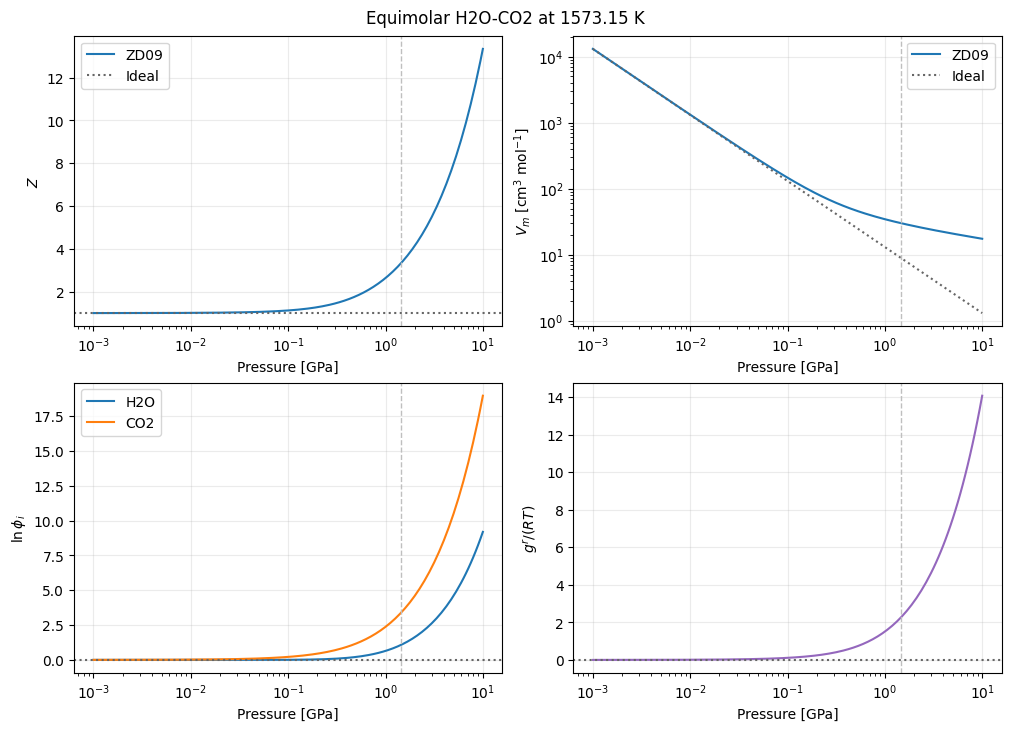

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.2), constrained_layout=True)

axes[0, 0].semilogx(pressure_gpa, states.Z, color="tab:blue", label="ZD09")
axes[0, 0].axhline(1.0, color="0.4", linestyle=":", label="Ideal")
axes[0, 0].set_ylabel(r"$Z$")
axes[0, 0].legend()

axes[0, 1].loglog(pressure_gpa, molar_volume, color="tab:blue", label="ZD09")
axes[0, 1].loglog(
    pressure_gpa, ideal_molar_volume, color="0.4", linestyle=":", label="Ideal"
)
axes[0, 1].set_ylabel(r"$V_m$ [cm$^3$ mol$^{-1}$]")
axes[0, 1].legend()

for index, name in enumerate(species):
    axes[1, 0].semilogx(pressure_gpa, states.lnphi[:, index], label=name)
axes[1, 0].axhline(0.0, color="0.4", linestyle=":")
axes[1, 0].set_ylabel(r"$\ln\phi_i$")
axes[1, 0].legend()

axes[1, 1].semilogx(pressure_gpa, states.gres_RT, color="tab:purple")
axes[1, 1].axhline(0.0, color="0.4", linestyle=":")
axes[1, 1].set_ylabel(r"$g^r/(RT)$")

for axis in axes.flat:
    axis.axvline(1.45, color="0.75", linestyle="--", linewidth=1.0)
    axis.set_xlabel("Pressure [GPa]")
    axis.grid(alpha=0.25)

fig.suptitle("Equimolar H2O-CO2 at 1573.15 K")
plt.show()


## Interpretation and limitations

- At 1 MPa the fluid is close to the ideal-gas limit: $Z=1.00098$ and both $\ln\phi_i$ values are close to zero.
- At 10 GPa, $Z=13.35$ and the ZD09 molar volume is far above the ideal-gas value. The rapidly increasing fugacity corrections show why a high-pressure-calibrated residual EOS matters for mantle-fluid chemical potentials.
- The plotted temperature and pressures remain inside the published H₂O–CO₂ P–T range; Table 7 does not specify a separate composition interval. The comparison above demonstrates model behavior and implementation consistency, not superiority to Peng–Robinson or another EOS.
- ExoEOS implements the homogeneous-fluid residual EOS from Zhang and Duan (2009), not the paper's standard chemical potentials or global speciation minimization. `phase="vapor"` selects the mechanically stable root connected to the low-density branch; it is not a vapor–liquid equilibrium calculation.
- `from_species` also supports CH₄, H₂, CO, O₂, and C₂H₆. H₂O–CH₄ has its own fitted interaction, while other binary pairs use unity cross parameters and the pure-species calibration ranges differ. Treat evaluations outside the relevant published range as extrapolation.
